## Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Preparation

In [3]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/BootGenAI/US_Superstore_data.xls')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

### Data Visualization with Matplotlib

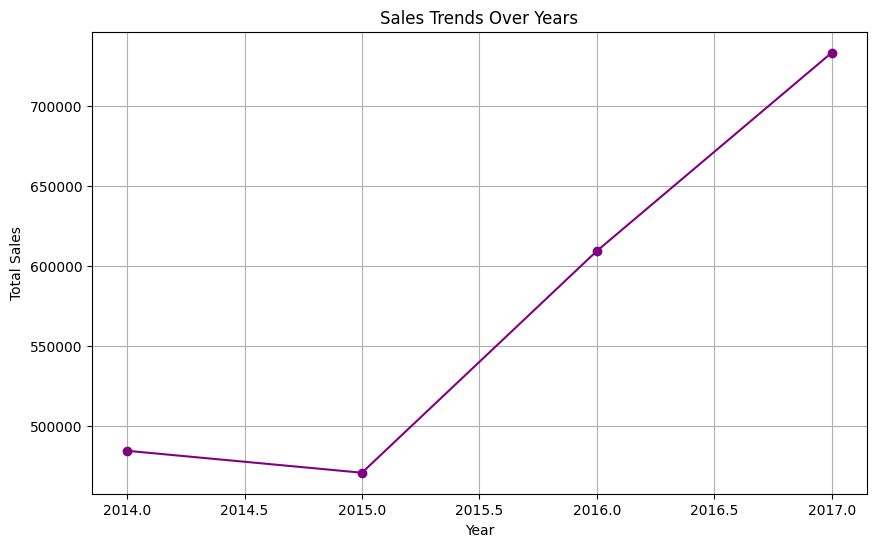

In [12]:
#Interactive Line Chart
import matplotlib.pyplot as plt

# Aggregate yearly sales
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='purple')
plt.title("Sales Trends Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

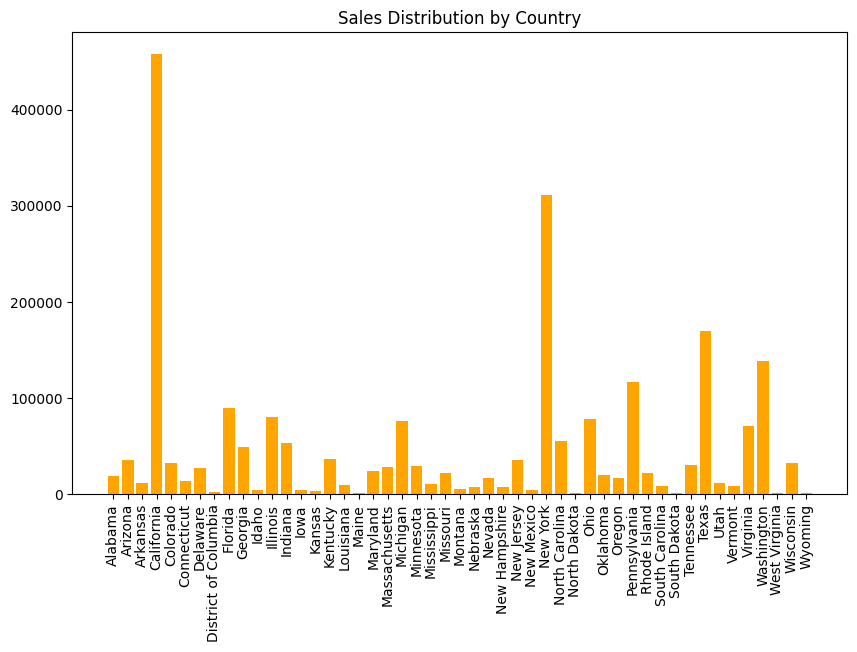

In [22]:
#Interactive Map with state cause we have one country US!!!
country_sales = df.groupby('State')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.bar(country_sales.index, country_sales.values, color='orange')
plt.title("Sales Distribution by Country")
plt.xticks(rotation=90)
plt.show()

### Data Visualization with Seaborn

/tmp/ipython-input-3061425493.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="flare")


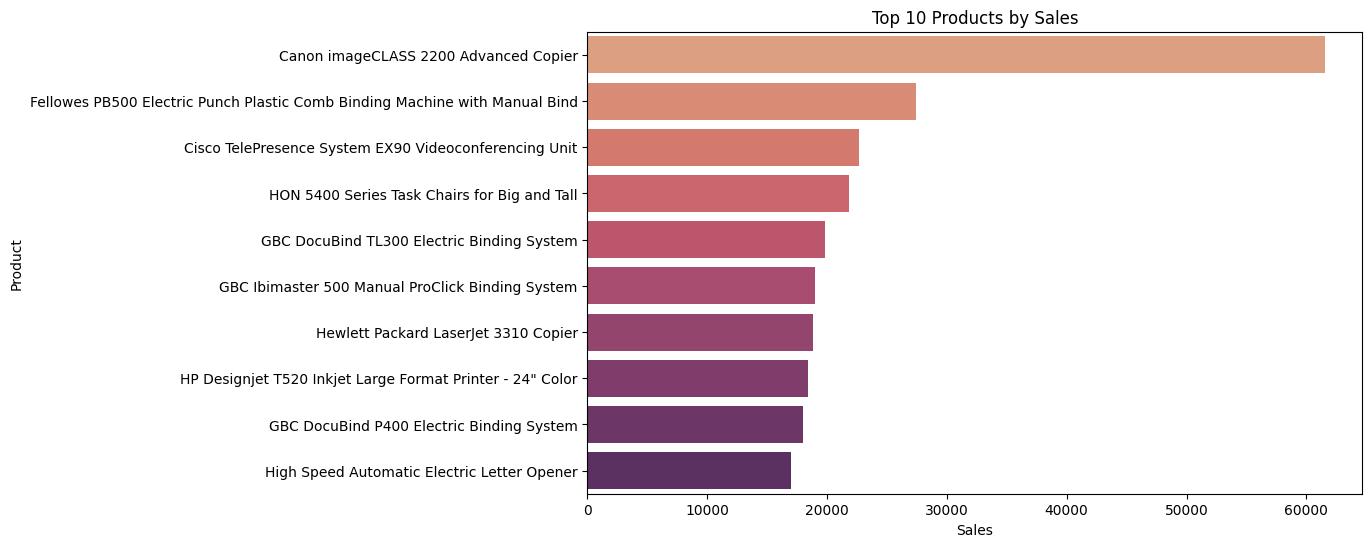

In [24]:
#top 10 products/sales
import seaborn as sns

top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="flare")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

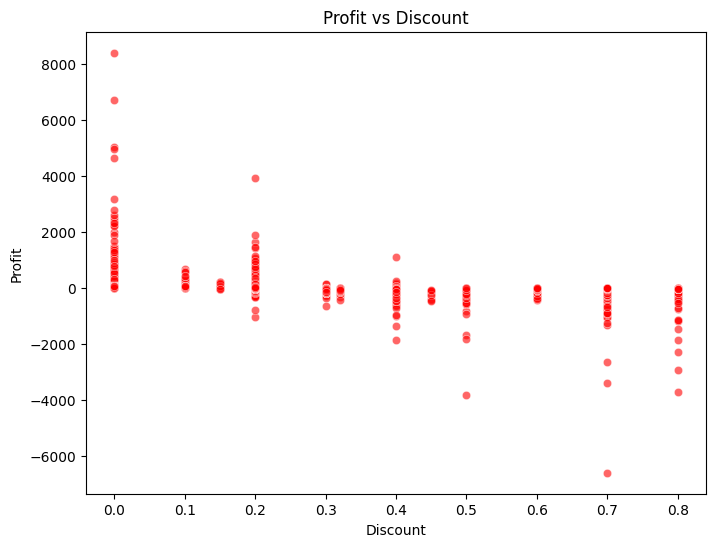

In [25]:
#Profit vs Discount Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6, color='red')
plt.title("Profit vs Discount")
plt.show()

**Comparative Analysis**
*Matplotlib*:

* Flexible, customizable, good for interactive trend plots.

* Requires more manual styling.

*Seaborn*:

* Elegant defaults, quick statistical plots.

* Easier for categorical comparisons (bar charts, scatter plots).